# Holdout Evaluation — CVD Risk Predictor
Final evaluation on the held-out 20% test set. These are the numbers reported in the paper.


In [1]:
import sys, os
os.chdir(r'C:\Users\preet\Projects\major-project')
sys.path.insert(0, r'C:\Users\preet\Projects\major-project')
print('Working dir:', os.getcwd())


Working dir: C:\Users\preet\Projects\major-project


### 1) Load Artifacts


In [2]:
import joblib
import pandas as pd

calibrator   = joblib.load('models/calibrator.pkl')
xgb_model    = joblib.load('models/xgboost_model.pkl')
logreg_model = joblib.load('models/logistic_model.pkl')

X_holdout = pd.read_csv('data/processed/X_holdout.csv')
y_holdout = pd.read_csv('data/processed/y_holdout.csv').iloc[:, 0]

print('Holdout shape:', X_holdout.shape)
print('Class distribution:', y_holdout.value_counts().to_dict())


Holdout shape: (732, 7)
Class distribution: {0: 621, 1: 111}


### 2) Evaluate All Models


In [3]:
from src.evaluation.metrics import evaluate_model, print_metrics_table, save_metrics

m_cal    = evaluate_model(calibrator,   X_holdout, y_holdout, model_name='XGBoost + Calibration (final)')
m_xgb    = evaluate_model(xgb_model,    X_holdout, y_holdout, model_name='XGBoost (uncalibrated)')
m_logreg = evaluate_model(logreg_model, X_holdout, y_holdout, model_name='Logistic Regression')

all_metrics = [m_cal, m_xgb, m_logreg]
print_metrics_table(all_metrics)



HOLDOUT EVALUATION RESULTS
                        model  auc_roc  auc_pr  brier  sensitivity  specificity     f1
XGBoost + Calibration (final)   0.6796  0.2831 0.1240       0.0541       0.9791 0.0923
       XGBoost (uncalibrated)   0.7089  0.3352 0.1182       0.0000       1.0000 0.0000
          Logistic Regression   0.7110  0.3621 0.1171       0.0270       1.0000 0.0526



### 3) Save Metrics


In [4]:
save_metrics(all_metrics, 'artifacts/metrics/holdout_metrics.csv')
print('Saved to artifacts/metrics/holdout_metrics.csv')


Saved to artifacts/metrics/holdout_metrics.csv


### 4) ROC Curves


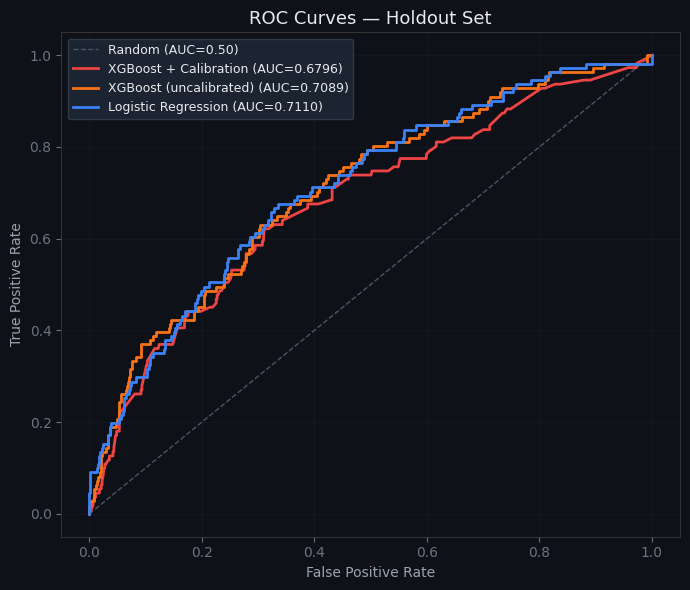

Saved roc_curves_holdout.png


In [5]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

matplotlib.rcParams['figure.facecolor'] = '#0e1117'
matplotlib.rcParams['axes.facecolor']   = '#0e1117'
matplotlib.rcParams['axes.edgecolor']   = '#333'
matplotlib.rcParams['text.color']       = '#e8eaf0'
matplotlib.rcParams['xtick.color']      = '#6b7280'
matplotlib.rcParams['ytick.color']      = '#6b7280'
matplotlib.rcParams['grid.color']       = '#1f2937'

models_to_plot = [
    (calibrator,   'XGBoost + Calibration', '#ef4444'),
    (xgb_model,    'XGBoost (uncalibrated)', '#f97316'),
    (logreg_model, 'Logistic Regression',    '#3b82f6'),
]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], '--', color='#4b5563', linewidth=1, label='Random (AUC=0.50)')

for model, name, color in models_to_plot:
    y_prob = model.predict_proba(X_holdout)[:, 1]
    fpr, tpr, _ = roc_curve(y_holdout, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')

ax.set_xlabel('False Positive Rate', color='#9ca3af')
ax.set_ylabel('True Positive Rate', color='#9ca3af')
ax.set_title('ROC Curves — Holdout Set', color='#e8eaf0', fontsize=13)
ax.legend(facecolor='#1f2937', edgecolor='#374151', labelcolor='#e8eaf0', fontsize=9)
ax.grid(True, alpha=0.3)

os.makedirs('artifacts/plots', exist_ok=True)
fig.tight_layout()
fig.savefig('artifacts/plots/roc_curves_holdout.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved roc_curves_holdout.png')


### 5) Precision-Recall Curves


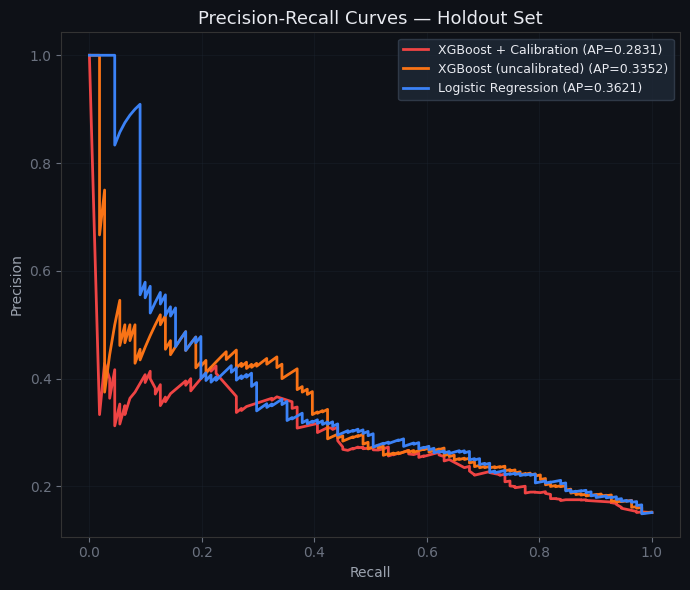

Saved pr_curves_holdout.png


In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))

for model, name, color in models_to_plot:
    y_prob = model.predict_proba(X_holdout)[:, 1]
    prec, rec, _ = precision_recall_curve(y_holdout, y_prob)
    ap = average_precision_score(y_holdout, y_prob)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', color='#9ca3af')
ax.set_ylabel('Precision', color='#9ca3af')
ax.set_title('Precision-Recall Curves — Holdout Set', color='#e8eaf0', fontsize=13)
ax.legend(facecolor='#1f2937', edgecolor='#374151', labelcolor='#e8eaf0', fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('artifacts/plots/pr_curves_holdout.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved pr_curves_holdout.png')


### 6) Log to W&B and Print Paper Numbers


In [8]:
from src.utils.wandb_logger import init_run, log_metrics, log_artifact, finish_run

run = init_run(
    run_name='holdout_evaluation',
    config_dict={'random_seed': 42, 'dataset_name': 'framingham', 'model_type': 'xgboost_calibrated_final'},
)
try:
    log_metrics({
        'holdout/auc_roc':     m_cal['auc_roc'],
        'holdout/auc_pr':      m_cal['auc_pr'],
        'holdout/brier':       m_cal['brier'],
        'holdout/sensitivity': m_cal['sensitivity'],
        'holdout/specificity': m_cal['specificity'],
        'holdout/f1':          m_cal['f1'],
        'holdout/accuracy':    m_cal['accuracy'],
    })
    log_artifact('artifacts/plots/roc_curves_holdout.png', 'plot',    'roc_curves_holdout')
    log_artifact('artifacts/plots/pr_curves_holdout.png',  'plot',    'pr_curves_holdout')
    log_artifact('artifacts/metrics/holdout_metrics.csv',  'metrics', 'holdout_metrics')
finally:
    finish_run()

print('\n--- PAPER NUMBERS (calibrated XGBoost, holdout set) ---')
for k in ['auc_roc','auc_pr','brier','sensitivity','specificity','f1','accuracy']:
    print(f'  {k:15s}: {m_cal[k]}')


Task was destroyed but it is pending!
task: <Task pending name='Task-180' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\preet\Projects\major-project\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-181' coro=<Kernel.shell_main() running at C:\Users\preet\Projects\major-project\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\preet\Projects\major-project\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\preet\AppData\Local\Programs\Python\Python313\Lib\collections\__init__.py:450: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @classmethod
Task was destroyed but it is pending!
task: <Task pending name='Task-181' coro=<Kernel.shell_main() running at C:\Users\preet\Projects\major-project\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


wandb: WARNING Artifact "roc_curves_holdout" already exists with the same content. No new version will be created.


holdout/accuracy,▁
holdout/auc_pr,▁
holdout/auc_roc,▁
holdout/brier,▁
holdout/f1,▁
holdout/sensitivity,▁
holdout/specificity,▁
holdout/accuracy,0.8388
holdout/auc_pr,0.2831
holdout/auc_roc,0.6796
holdout/brier,0.124



--- PAPER NUMBERS (calibrated XGBoost, holdout set) ---
  auc_roc        : 0.6796
  auc_pr         : 0.2831
  brier          : 0.124
  sensitivity    : 0.0541
  specificity    : 0.9791
  f1             : 0.0923
  accuracy       : 0.8388
